## Importing Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
import os

## Defining constants and file paths

In [2]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

base_dir = './dataset'
train_dir = os.path.join(base_dir, 'train/train')
val_dir = os.path.join(base_dir, 'Sample_fake_images/Sample_fake_images')
test_dir = os.path.join(base_dir, 'test/test')

## Data Augmentation and Preprocessing

In [3]:
train_datagen = ImageDataGenerator(
    rotation_range=20,           # Slight rotations
    width_shift_range=0.1,       # Slight horizontal shifts
    height_shift_range=0.1,      # Slight vertical shifts
    shear_range=0.1,             # Shearing transformations
    zoom_range=0.1,              # Slight zooming in/out
    horizontal_flip=True,        # Flip images horizontally
    fill_mode='nearest',          # Strategy for filling in newly created pixels
    validation_split=0.20         # Reserve 20% of the training data for validation
)

test_datagen = ImageDataGenerator() # No augmentation for test data, just rescaling if needed


## Loading Data using flow_from_directory

In [4]:
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH), # Resizes all images to 224x224
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    subset='training'                    # Use the 80% training subset
)

print("Loading Validation Data:")
validation_generator = train_datagen.flow_from_directory(
    train_dir,                           # Point to the Train folder again!
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    subset='validation'                  # Uses the reserved 20% half
)

print("Loading Test Data:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False                        # No need to shuffle test data
)

Loading Training Data:
Found 384 images belonging to 2 classes.
Loading Validation Data:
Found 95 images belonging to 2 classes.
Loading Test Data:
Found 499 images belonging to 2 classes.


In [5]:
base_model = EfficientNetB0(
    weights='imagenet',       # Use weights trained on millions of images
    include_top=False,        # Drop the original 1000-class ImageNet classifier
    input_shape=(224, 224, 3)
)

# 2. Freeze the base model layers (Crucial for the first phase of training)
base_model.trainable = False

# 3. Build our custom classification head on top of it
x = base_model.output
x = GlobalAveragePooling2D()(x)       # Flattens the output efficiently
x = BatchNormalization()(x)
x = Dropout(0.5)(x)                   # Heavy dropout to prevent overfitting
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # Binary output (Real/Fake)

# 4. Combine into the final model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,713,124 (17.98 MB)

 Trainable params: 659,969 (2.52 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

## Training the model with callbacks

In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,          # Stop if validation loss doesn't improve for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,          # Reduce learning rate by 80% if it plateaus
    patience=3,
    min_lr=1e-6
)

In [7]:
from sklearn.utils import class_weight
import numpy as np

train_classes = train_generator.classes

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)

class_weight_dict = dict(enumerate(class_weights_array))

print(f"Calculated Class Weights: {class_weight_dict}")

Calculated Class Weights: {0: np.float64(1.5609756097560976), 1: np.float64(0.735632183908046)}


In [8]:
history = model.fit(
    train_generator,
    epochs=20, # Early stopping will likely halt this earlier
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/20
 9/12 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step - accuracy: 0.4629 - loss: 1.1438

/Users/skakibahammed/code_playground/Model_Repo/image_detect/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5521 - loss: 1.0134 - val_accuracy: 0.5789 - val_loss: 0.6784 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 886ms/step - accuracy: 0.7214 - loss: 0.6093 - val_accuracy: 0.6421 - val_loss: 0.6658 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 771ms/step - accuracy: 0.7526 - loss: 0.5502 - val_accuracy: 0.6842 - val_loss: 0.6173 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 783ms/step - accuracy: 0.8073 - loss: 0.4410 - val_accuracy: 0.7474 - val_loss: 0.5652 - learning_rate: 0.0010
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 762ms/step - accuracy: 0.8099 - loss: 0.4540 - val_accuracy: 0.7579 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 774ms/step - accuracy: 0.8333 - loss: 0.4001 - val_accuracy: 0.7474 - val_loss: 0.4686 - learning_rate: 0.0010
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 801ms/step - accuracy: 0.8438 - loss: 0.3247 - val_accura

## Evaluating the model on the test dataset

In [9]:
def evaluate_on_test_set(model, test_gen):
    print("Evaluating model on the test dataset...")
    test_loss, test_accuracy = model.evaluate(test_gen)

    print("-" * 30)
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Loss:     {test_loss:.4f}")
    print("-" * 30)

In [10]:
evaluate_on_test_set(model, test_generator)

Evaluating model on the test dataset...
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 542ms/step - accuracy: 0.7475 - loss: 0.5451
------------------------------
Test Accuracy: 74.75%
Test Loss:     0.5451
------------------------------


## Fine-tuning the model by unfreezing some layers of the base model

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 1e-5 is 100x smaller than your previous 1e-3
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("Starting Fine-Tuning Phase...")
history_finetune = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,713,124 (17.98 MB)

 Trainable params: 2,156,129 (8.22 MB)

 Non-trainable params: 2,556,995 (9.75 MB)

Starting Fine-Tuning Phase...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8490 - loss: 0.3732 - val_accuracy: 0.7895 - val_loss: 0.4885 - learning_rate: 1.0000e-05
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8568 - loss: 0.3274 - val_accuracy: 0.8000 - val_loss: 0.4678 - learning_rate: 1.0000e-05
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8542 - loss: 0.3822 - val_accuracy: 0.7579 - val_loss: 0.4918 - learning_rate: 1.0000e-05
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8568 - loss: 0.3574 - val_accuracy: 0.7684 - val_loss: 0.5291 - learning_rate: 2.0000e-06
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8516 - loss: 0.4143 - val_accuracy: 0.7684 - val_loss: 0.5055 - learning_rate: 2.0000e-06


In [12]:
evaluate_on_test_set(model, test_generator)

Evaluating model on the test dataset...
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 633ms/step - accuracy: 0.7455 - loss: 0.5481
------------------------------
Test Accuracy: 74.55%
Test Loss:     0.5481
------------------------------


## Generating a Confusion Matrix

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0

/Users/skakibahammed/code_playground/Model_Repo/image_detect/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 421ms/step


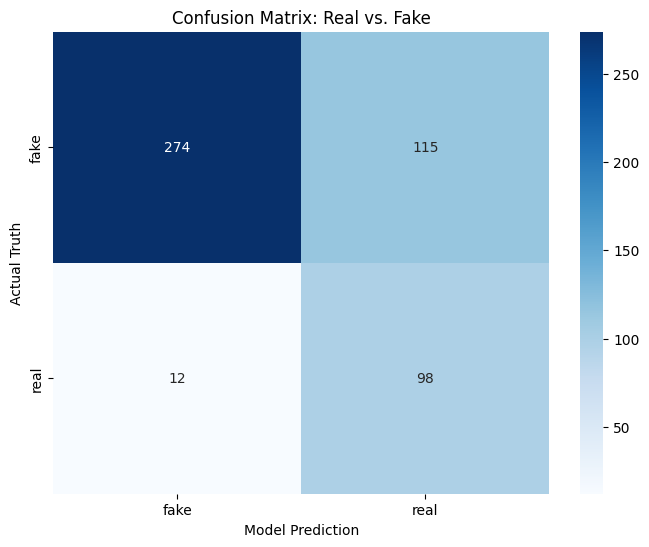


Detailed Classification Report:
              precision    recall  f1-score   support

        fake       0.96      0.70      0.81       389
        real       0.46      0.89      0.61       110

    accuracy                           0.75       499
   macro avg       0.71      0.80      0.71       499
weighted avg       0.85      0.75      0.77       499



In [13]:
%pip install seaborn matplotlib

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()

true_labels = test_generator.classes

print("Generating predictions...")
predictions = model.predict(test_generator)

predicted_labels = (predictions > 0.5).astype(int).reshape(-1)

class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Real vs. Fake')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

## trying a different model

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_datagen_x = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <--- CRITICAL FOR XCEPTION
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.20
)

test_datagen_x = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_x = train_datagen_x.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
    subset='training'
)

validation_generator_x = train_datagen_x.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    subset='validation'
)

test_generator_x = test_datagen_x.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 384 images belonging to 2 classes.
Found 95 images belonging to 2 classes.
Found 499 images belonging to 2 classes.


In [6]:
# Load pre-trained Xception without the top layer
xception_base = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers for Phase 1 of Transfer Learning
xception_base.trainable = False

# Attach Custom Head
x = xception_base.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

xception_model = Model(inputs=xception_base.input, outputs=predictions)

# Compile
xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print confirmation
print("Xception Model successfully compiled and ready for training!")

Xception Model successfully compiled and ready for training!


In [23]:
xception_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_12[0][0]    

 Total params: 21,921,321 (83.62 MB)

 Trainable params: 1,054,721 (4.02 MB)

 Non-trainable params: 20,866,600 (79.60 MB)

In [24]:
history = xception_model.fit(
    train_generator_x,                       # <--- FIXED
    epochs=20,
    validation_data=validation_generator_x,  # <--- FIXED
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6224 - loss: 0.9497 - val_accuracy: 0.4632 - val_loss: 0.8028 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7630 - loss: 0.6089 - val_accuracy: 0.5579 - val_loss: 0.7627 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7917 - loss: 0.4736 - val_accuracy: 0.7789 - val_loss: 0.5207 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7812 - loss: 0.4873 - val_accuracy: 0.7579 - val_loss: 0.6043 - learning_rate: 2.0000e-04
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8021 - loss: 0.4911 - val_accuracy: 0.7474 - val_loss: 0.5651 - learning_rate: 2.0000e-04


In [10]:
evaluate_on_test_set(xception_model, test_generator_x)

Evaluating model on the test dataset...


/Users/skakibahammed/code_playground/Model_Repo/image_detect/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7635 - loss: 0.5864
------------------------------
Test Accuracy: 76.35%
Test Loss:     0.5864
------------------------------


In [8]:
xception_model.save('xception_deepfake_base.keras')
print("Model saved successfully as 'xception_deepfake_base.keras'")

Model saved successfully as 'xception_deepfake_base.keras'


In [13]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Evaluating Xception Model on Test Set...")

test_generator_x.reset()

preds = xception_model.predict(test_generator_x, steps=len(test_generator_x), verbose=1)

all_predictions = (preds > 0.5).astype(int).flatten()

all_labels = test_generator_x.classes

class_labels_dict = test_generator_x.class_indices
target_names = [name for name, index in sorted(class_labels_dict.items(), key=lambda x: x[1])]

unique_true, counts_true = np.unique(all_labels, return_counts=True)
print(f"\nTrue labels in test set: {dict(zip(unique_true, counts_true))}")

unique_preds, counts_preds = np.unique(all_predictions, return_counts=True)
print(f"Model predictions: {dict(zip(unique_preds, counts_preds))}")

Evaluating Xception Model on Test Set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step

True labels in test set: {np.int32(0): np.int64(389), np.int32(1): np.int64(110)}
Model predictions: {np.int64(0): np.int64(469), np.int64(1): np.int64(30)}



Classification Report:
              precision    recall  f1-score   support

        fake       0.79      0.95      0.86       389
        real       0.37      0.10      0.16       110

    accuracy                           0.76       499
   macro avg       0.58      0.53      0.51       499
weighted avg       0.70      0.76      0.71       499

Accuracy: 76.35%



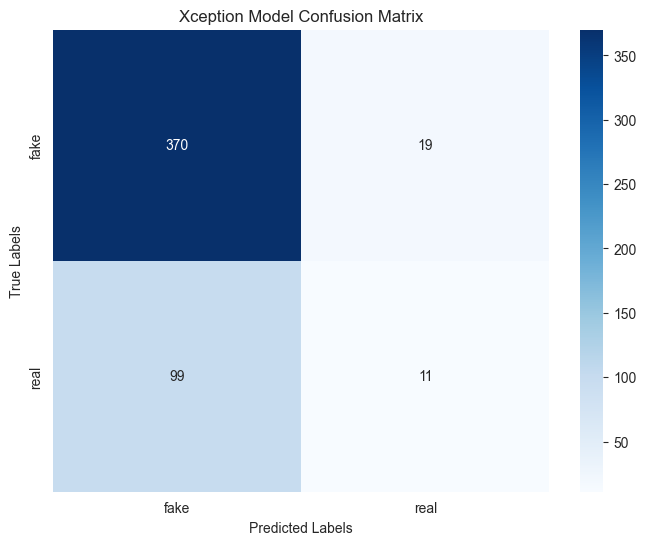

In [14]:
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=target_names, zero_division=0))

accuracy = accuracy_score(all_labels, all_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Xception Model Confusion Matrix')
plt.show()